In [ ]:
WIDTH = 9
HEIGHT = 9
NUM_AGENTS = 4

In [1]:
import sys
sys.path.append('../../..')
import pickle
import pandas as pd

In [ ]:
df_val: pd.DataFrame = pickle.load(open(f'predicted_trajectory_values_{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}.pkl', 'rb'))


In [ ]:
df_ir: pd.DataFrame = pickle.load(open(f'predicted_trajectory_ir_{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}.pkl', 'rb'))

In [4]:
print(df_ir.keys())

Index(['state_index', 'timestep', 'true_reward_A0', 'pred_reward_A0',
       'error_A0', 'true_reward_A1', 'pred_reward_A1', 'error_A1',
       'total_reward_error', 'state_object'],
      dtype='object')


In [5]:
print(f"average error agent 0: {df_ir['error_A0'].mean()}")
print(f"average true reward agent 0: {df_ir['true_reward_A0'].mean()}")
print(f"average error agent 1: {df_ir['error_A1'].mean()}")
print(f"average true reward agent 1: {df_ir['true_reward_A1'].mean()}")

average error agent 0: 0.03840858549054712
average true reward agent 0: 0.14339875
average error agent 1: 0.03327843391983304
average true reward agent 1: 0.1428775


In [6]:
print(df_val.keys())

Index(['timestep', 'centralized_team_value', 'decentralized_team_value',
       'error', 'centralized - decentralized', 'state_object'],
      dtype='object')


In [7]:
print(df_val['error'].mean())


0.3971567833650112


In [8]:
# --- Step 1: Verification ---
# Ensure DataFrames align perfectly before merging
assert len(df_val) == len(df_ir), "DataFrames length mismatch!"
# Check first and last state objects to ensure trajectory alignment
assert df_val.iloc[0]['state_object'] == df_ir.iloc[0]['state_object'], "Start state mismatch!"
assert df_val.iloc[-1]['state_object'] == df_ir.iloc[-1]['state_object'], "End state mismatch!"

print("✅ Verification successful: DataFrames align.")

# --- Step 2: Select Columns and Merge ---
# We want these specific columns from the IR DataFrame
ir_cols = [
    'true_reward_A0', 'pred_reward_A0', 'error_A0',
    'true_reward_A1', 'pred_reward_A1', 'error_A1',
    'total_reward_error'
]

# Merge on index (axis=1)
df_combined = pd.concat([df_val, df_ir[ir_cols]], axis=1)

# Define the list of columns we want to display in our report later
display_cols = [
    'timestep',
    'centralized_team_value', 'decentralized_team_value', 'error', # Value Info
    'true_reward_A0', 'pred_reward_A0', 'error_A0',                # Agent 0 Reward Info
    'true_reward_A1', 'pred_reward_A1', 'error_A1'                 # Agent 1 Reward Info
]

print("Data merged. Ready for analysis.")

✅ Verification successful: DataFrames align.
Data merged. Ready for analysis.


In [9]:
N_STATES = 10  # Number of states to analyze for each group

# Sort by Value Error (descending)
df_sorted = df_combined.sort_values(by='error', ascending=False)

# Get the N Worst (Highest Value Error)
worst_states = df_sorted.head(N_STATES)

# Get the N Best (Lowest Value Error)
best_states = df_sorted.tail(N_STATES)

# --- Helper Function to Print Analysis ---
def analyze_subset(subset_df, title):
    print(f"\n{'='*30} {title} {'='*30}")
    # 1. Print the Data Table
    print(subset_df[display_cols].to_string(index=False))

# --- Run the Analysis ---

analyze_subset(worst_states, "WORST Value Predictions (Highest Error)")
analyze_subset(best_states, "BEST Value Predictions (Lowest Error)")
# --- Optional: Visualizing the #1 Worst State ---



============================== WORST Value Predictions (Highest Error) ==============================
 timestep  centralized_team_value  decentralized_team_value    error  true_reward_A0  pred_reward_A0  error_A0  true_reward_A1  pred_reward_A1  error_A1
  31972.0               28.471640                 32.483663 4.012023             0.0       -0.054251  0.054251             0.0        0.021737  0.021737
 239347.5               28.557394                 32.107849 3.550455             0.0        0.062927  0.062927             0.0        0.501615  0.501615
 239348.0               28.557394                 32.107849 3.550455             0.0        0.062927  0.062927             0.0        0.501615  0.501615
  96421.0               28.531530                 31.927033 3.395503             0.0        0.073188  0.073188             0.0        0.722269  0.722269
 333192.0               28.171225                 31.549493 3.378268             0.0        0.050009  0.050009             0.0      

In [10]:
for idx, row in worst_states.iterrows():
    print(f"\n{'='*30} VISUALIZING WORST STATE at Timestep {row['timestep']} {'='*30}")
    print(row['state_object'])


============================== VISUALIZING WORST STATE at Timestep 31972.0 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (0, 2)
  Agent 1: (0, 2)

--- Agents (Count) ---
. . 2 . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
. . . . . .
. . . . . .
. . . . . 1
. . . . 1 1
. . 1 1 . 1
1 1 1 . 1 1

============================== VISUALIZING WORST STATE at Timestep 239347.5 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (0, 4)
  Agent 1: (0, 4)

--- Agents (Count) ---
. . . . 2 .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
1 . . . . .
. . . . . .
1 1 . 1 . .
1 . 1 1 . .
1 1 . . 1 .
1 . 1 1 1 .

============================== VISUALIZING WORST STATE at Timestep 239348.0 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (0, 4)
  Agent 1: (0, 4)

--- Agents (C

In [11]:
for idx, row in reversed(list(best_states.iterrows())):
    print(f"\n{'='*30} VISUALIZING BEST STATE at Timestep {row['timestep']} {'='*30}")
    print(row['state_object'])


============================== VISUALIZING BEST STATE at Timestep 326991.0 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (2, 3)
  Agent 1: (3, 1)

--- Agents (Count) ---
. . . . . .
. . . . . .
. . . 1 . .
. 1 . . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
. . . . . .
1 . . . . .
. . . . . .
1 . . 1 . .
. . . . 1 .
1 . 1 1 . .

============================== VISUALIZING BEST STATE at Timestep 248328.0 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (3, 2)
  Agent 1: (1, 2)

--- Agents (Count) ---
. . . . . .
. . 1 . . .
. . . . . .
. . 1 . . .
. . . . . .
. . . . . .

--- Apples (Count) ---
. . . . . .
1 . . . 1 .
. . . . . 1
. 1 . . 1 .
1 . . . . .
. . 1 . . .

============================== VISUALIZING BEST STATE at Timestep 350453.0 ==============================
--- Empty State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (4, 1)
  Agent 1: (2, 0)

--- Agents (Cou

Generating plots for N=10...
✅ Verified: States match perfectly for all 10 entries in 'Top 10 WORST Value Predictions'.


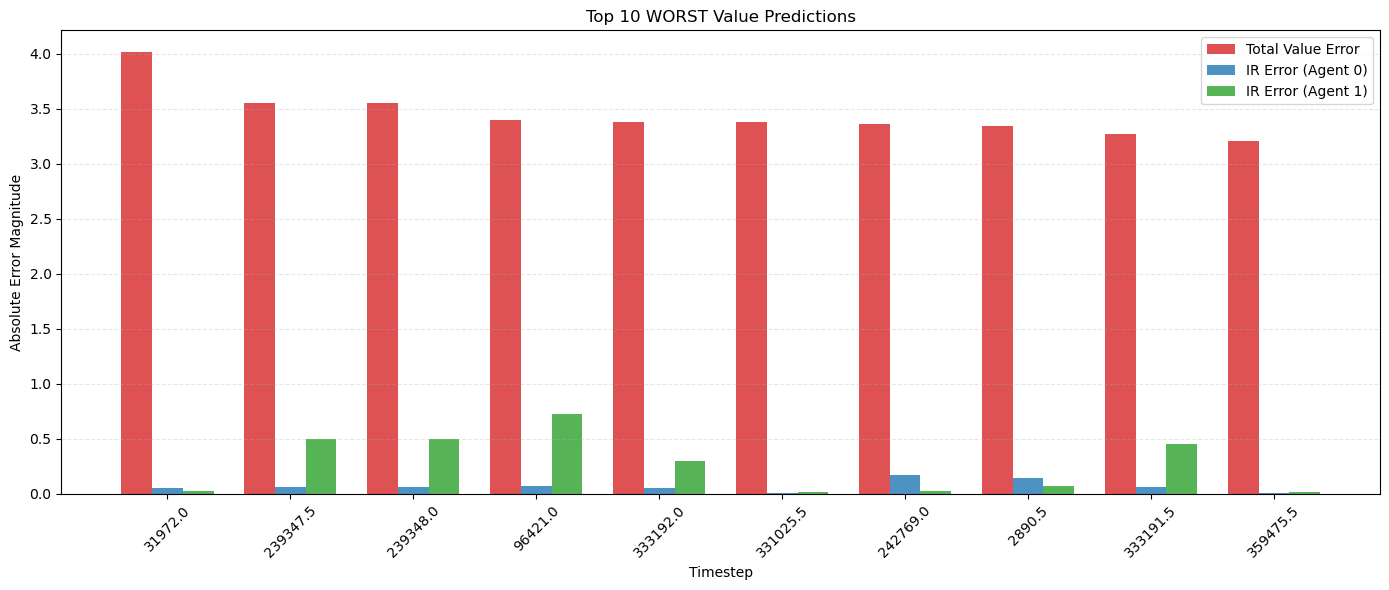

✅ Verified: States match perfectly for all 10 entries in 'Top 10 BEST Value Predictions'.


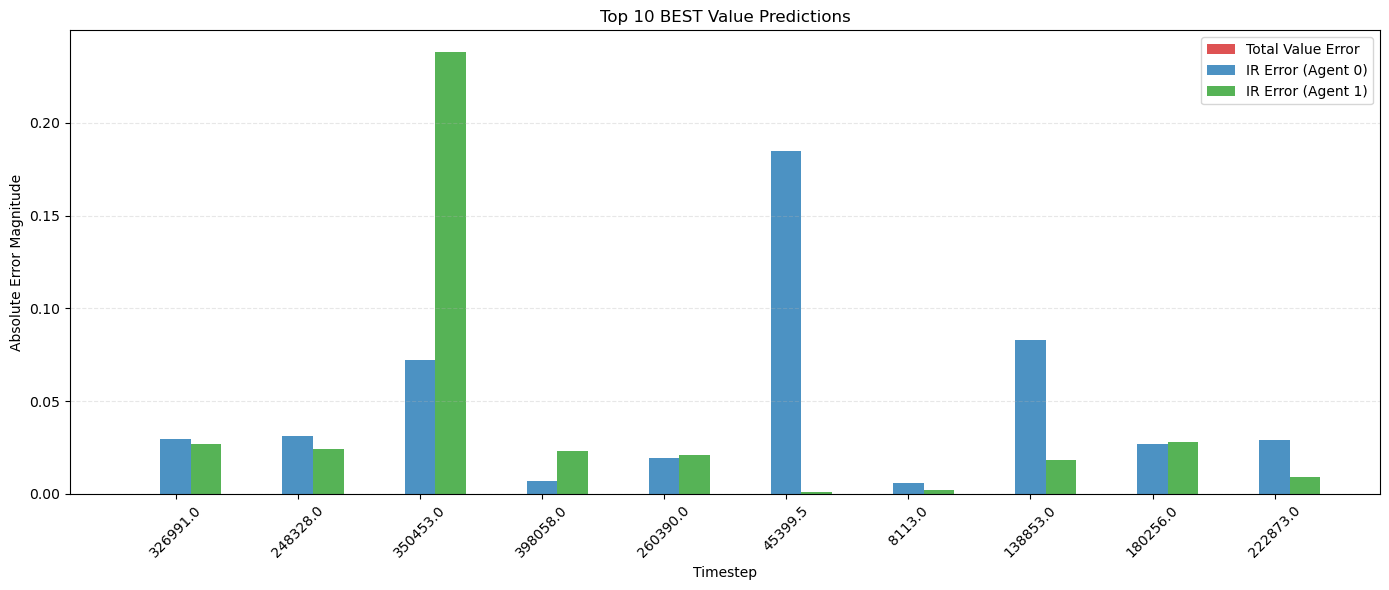

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def verify_and_plot(subset_df, title):
    """
    Verifies state consistency and plots Value Error vs IR Errors.
    """
    # --- 1. Rigorous Verification ---
    # We iterate through the specific indices of this subset
    subset_indices = subset_df.index
    
    for idx in subset_indices:
        # Retrieve the state object from the ORIGINAL source dataframes
        state_from_val = df_val.loc[idx]['state_object']
        state_from_ir = df_ir.loc[idx]['state_object']
        
        # Check that they are the exact same object or at least equal
        if state_from_val != state_from_ir:
            raise ValueError(f"CRITICAL FAILURE: State mismatch at index {idx}!")
            
    print(f"✅ Verified: States match perfectly for all {len(subset_df)} entries in '{title}'.")

    # --- 2. Plotting ---
    timesteps = subset_df['timestep'].values
    
    # Data to plot
    value_errors = subset_df['error'].values
    ir_errors_a0 = subset_df['error_A0'].values
    ir_errors_a1 = subset_df['error_A1'].values
    
    x = np.arange(len(timesteps))  # Label locations
    width = 0.25  # Width of the bars

    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Create grouped bars
    rects1 = ax.bar(x - width, value_errors, width, label='Total Value Error', color='#d62728', alpha=0.8)
    rects2 = ax.bar(x, ir_errors_a0, width, label='IR Error (Agent 0)', color='#1f77b4', alpha=0.8)
    rects3 = ax.bar(x + width, ir_errors_a1, width, label='IR Error (Agent 1)', color='#2ca02c', alpha=0.8)

    # Formatting
    ax.set_ylabel('Absolute Error Magnitude')
    ax.set_xlabel('Timestep')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(timesteps, rotation=45)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add text annotations if IR errors are too small to see
    # (Optional, but helps if IR errors are tiny vs Value errors)
    # ax.bar_label(rects1, padding=3, fmt='%.2f')
    
    plt.tight_layout()
    plt.show()

# --- Configuration ---
N_SAMPLES = 10

# --- Get Data Subsets ---
# 1. Worst States (Highest Value Error)
df_worst = df_combined.sort_values(by='error', ascending=False).head(N_SAMPLES)

# 2. Best States (Lowest Value Error)
df_best = df_combined.sort_values(by='error', ascending=True).head(N_SAMPLES)

# --- Execute ---
print(f"Generating plots for N={N_SAMPLES}...")
verify_and_plot(df_worst, f"Top {N_SAMPLES} WORST Value Predictions")
verify_and_plot(df_best, f"Top {N_SAMPLES} BEST Value Predictions")

--- Correlation Statistics ---
Pearson Correlation (Linear): 0.0591
Spearman Correlation (Rank):  0.0321
Interpretation: A low correlation suggests distinct failure modes.


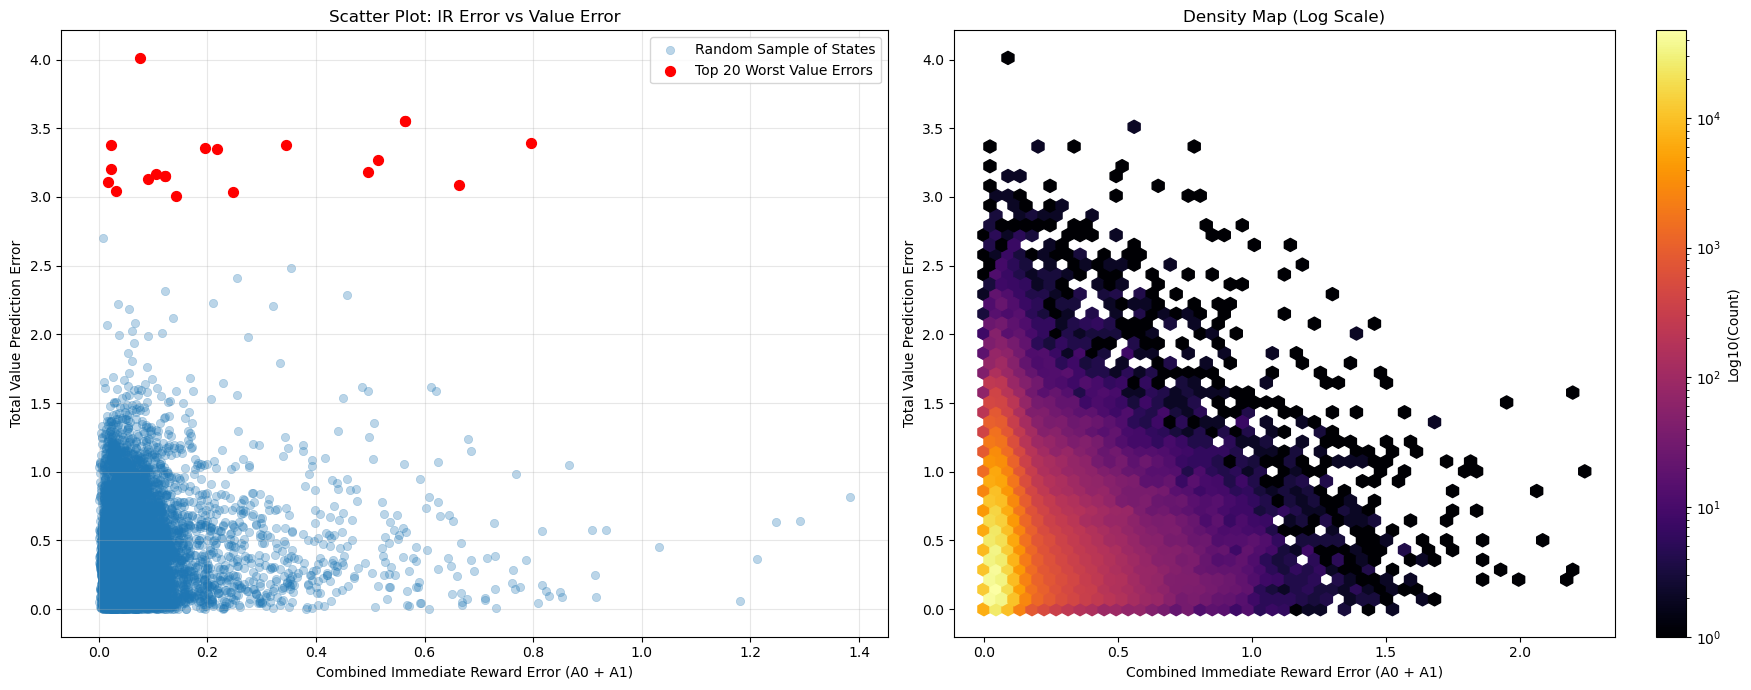

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- 1. Prepare Data ---
# Create a metric for Total IR Error (sum of individual errors)
df_combined['sum_ir_error'] = df_combined['error_A0'] + df_combined['error_A1']

# --- 2. Calculate Correlation Coefficients ---
p_corr, _ = pearsonr(df_combined['sum_ir_error'], df_combined['error'])
s_corr, _ = spearmanr(df_combined['sum_ir_error'], df_combined['error'])

print(f"--- Correlation Statistics ---")
print(f"Pearson Correlation (Linear): {p_corr:.4f}")
print(f"Spearman Correlation (Rank):  {s_corr:.4f}")
print(f"Interpretation: A low correlation suggests distinct failure modes.")

# --- 3. Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot A: Scatter Plot with Outliers Highlighted ---
# Sample the data if it's huge to speed up plotting, but keep outliers
df_sample = df_combined.sample(min(10000, len(df_combined)), random_state=42)

sns.scatterplot(
    data=df_sample, 
    x='sum_ir_error', 
    y='error', 
    alpha=0.3, 
    ax=axs[0],
    color='#1f77b4',
    edgecolor=None,
    label='Random Sample of States'
)

# Highlight the Top 20 Worst Value Errors in RED
top_20_worst = df_combined.sort_values(by='error', ascending=False).head(20)
axs[0].scatter(
    top_20_worst['sum_ir_error'], 
    top_20_worst['error'], 
    color='red', 
    s=50, 
    label='Top 20 Worst Value Errors',
    zorder=5
)

axs[0].set_title("Scatter Plot: IR Error vs Value Error")
axs[0].set_xlabel("Combined Immediate Reward Error (A0 + A1)")
axs[0].set_ylabel("Total Value Prediction Error")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Plot B: Density Heatmap (Log Scale) ---
# This shows where the majority of points truly lie
hb = axs[1].hexbin(
    df_combined['sum_ir_error'], 
    df_combined['error'], 
    gridsize=50, 
    cmap='inferno', 
    bins='log', 
    mincnt=1
)
cb = fig.colorbar(hb, ax=axs[1], label='Log10(Count)')
axs[1].set_title("Density Map (Log Scale)")
axs[1].set_xlabel("Combined Immediate Reward Error (A0 + A1)")
axs[1].set_ylabel("Total Value Prediction Error")

plt.tight_layout()
plt.show()